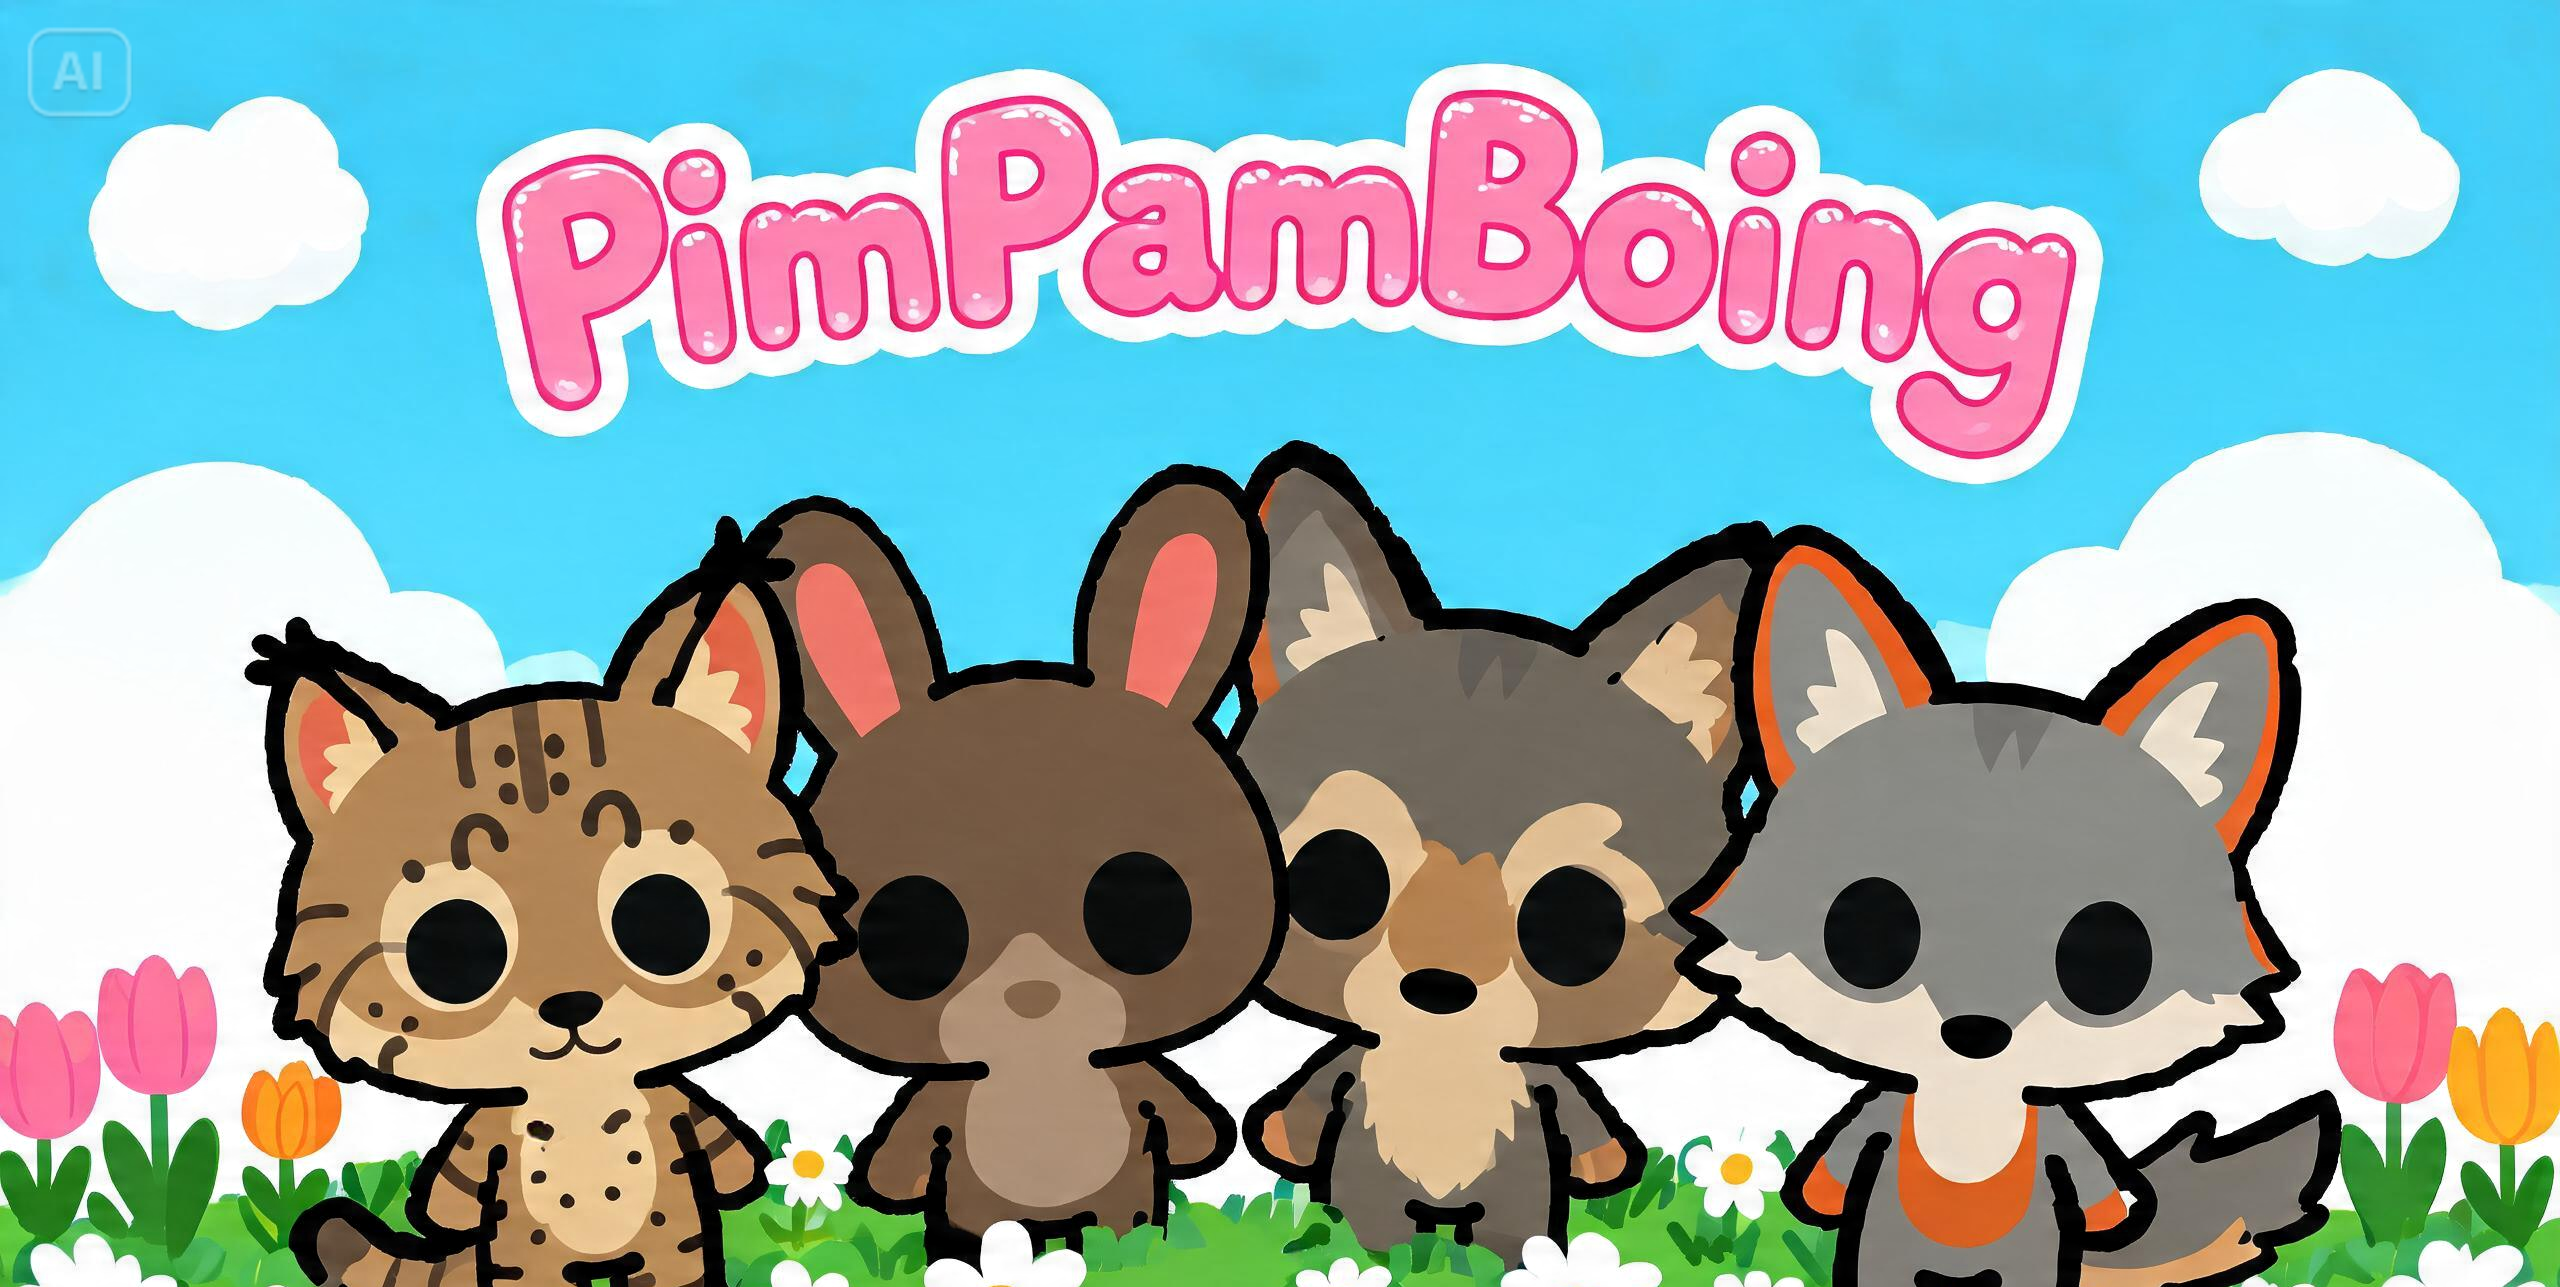

In [5]:
from IPython.display import Image
Image("C:/Users/Lilir/Downloads/animal.png")

<div style="background-color:#F4F5F7; padding:34px 42px; border-radius:8px; border:1px solid #E1E4E8; margin-bottom:18px;">
<p style="color:#6B7280; font-size:12px; font-weight:600; letter-spacing:2px; text-transform:uppercase; margin:0 0 10px 0;">Análisis Exploratorio de Datos</p>
<h1 style="color:#2C2C2C; margin:0; font-size:30px; font-weight:700;">PimPamBoing — VividChroma Games</h1>
<p style="color:#5A5A5A; font-size:14.5px; margin:10px 0 0 0;">Ventas de mercancía física, estado de Puebla</p>
</div>

<div style="background-color:#FAFAFA; padding:22px 30px; border-radius:6px; border-left:4px solid #5B7C99; margin-bottom:18px;">
<h3 style="color:#2C2C2C; margin-top:0; font-size:15.5px;">Contexto</h3>
<p style="color:#4A4A4A; font-size:14px; line-height:1.7; text-align:justify; margin-bottom:10px;">
PimPamBoing es un videojuego infantil de VividChroma Games que integra una tienda virtual de mercancía física relacionada con el juego: mochilas, stickers, vasos, libretas, peluches y cómics. Las operaciones de venta de esta mercancía se concentran en el estado de Puebla.
</p>
<p style="color:#4A4A4A; font-size:14px; line-height:1.7; text-align:justify; margin:0;">
Este notebook trabaja sobre el dataset ya limpio y unificado que produce el proceso de ETL (<code>dataset_maestro_vividchroma.csv</code>), y responde un conjunto de preguntas de negocio mediante análisis exploratorio y visualización.
</p>
</div>

<div style="background-color:#FAFAFA; padding:22px 30px; border-radius:6px; border-left:4px solid #7C9885; margin-bottom:18px;">
<h3 style="color:#2C2C2C; margin-top:0; font-size:15.5px;">Preguntas de negocio</h3>
<ol style="color:#4A4A4A; font-size:14px; line-height:1.9; margin:0; padding-left:20px;">
<li>¿Cómo se comportan las ventas en el tiempo (día, semana, mes, año, estacionalidad)?</li>
<li>¿Cuáles son los productos más y menos vendidos, y cuáles dejan más utilidad?</li>
<li>¿Quiénes son los clientes frecuentes y qué patrones de compra siguen?</li>
<li>¿En qué municipios o zonas de Puebla se concentran más las ventas?</li>
<li>¿Cómo evoluciona la rentabilidad del negocio a lo largo del tiempo?</li>
</ol>
</div>

<div style="background-color:#FAFAFA; padding:20px 30px; border-radius:6px; border:1px solid #E1E4E8; margin-bottom:18px;">
<table style="width:100%; border-collapse:collapse;">
<tr><td style="padding:8px 14px; color:#8A8A8A; font-size:12.5px; font-weight:600; width:200px;">PROGRAMA</td><td style="padding:8px 14px; color:#2C2C2C; font-size:13.5px;">Ingeniería en Entornos Virtuales y Negocios Digitales</td></tr>
<tr><td style="padding:8px 14px; color:#8A8A8A; font-size:12.5px; font-weight:600;">ASIGNATURA</td><td style="padding:8px 14px; color:#2C2C2C; font-size:13.5px;">Analítica de Datos para Negocios Digitales</td></tr>
<tr><td style="padding:8px 14px; color:#8A8A8A; font-size:12.5px; font-weight:600;">DOCENTE</td><td style="padding:8px 14px; color:#2C2C2C; font-size:13.5px;">M.T.I. Marco A. Ramírez Hernández</td></tr>
<tr><td style="padding:8px 14px; color:#8A8A8A; font-size:12.5px; font-weight:600;">PERIODO</td><td style="padding:8px 14px; color:#2C2C2C; font-size:13.5px;">Mayo - Agosto 2026</td></tr>
<tr><td style="padding:8px 14px; color:#8A8A8A; font-size:12.5px; font-weight:600; vertical-align:top;">INTEGRANTES</td><td style="padding:8px 14px; color:#2C2C2C; font-size:13.5px; line-height:1.8;">
Liliana Rosales Gómez · Samantha Salazar Fernández · Ilse Guadalupe Saavedra Villa · Adriana Rosales Gayoso · Angélica Citlali Gutiérrez Ortega
</td></tr>
</table>
</div>

<div style="background-color:#FAFAFA; padding:20px 30px; border-radius:6px; border:1px solid #E1E4E8; margin-bottom:26px;">
<h3 style="color:#2C2C2C; margin-top:0; font-size:15.5px;">Librerías utilizadas</h3>
<table style="width:100%; border-collapse:collapse;">
<tr><td style="padding:6px 14px; color:#5B7C99; font-size:13px; font-weight:600; width:150px; vertical-align:top;">pandas / numpy</td><td style="padding:6px 14px; color:#4A4A4A; font-size:13px;">Carga, limpieza y agregación de los datos.</td></tr>
<tr><td style="padding:6px 14px; color:#5B7C99; font-size:13px; font-weight:600; vertical-align:top;">matplotlib / seaborn</td><td style="padding:6px 14px; color:#4A4A4A; font-size:13px;">Gráficas estadísticas (barras, líneas, dispersión).</td></tr>
<tr><td style="padding:6px 14px; color:#5B7C99; font-size:13px; font-weight:600; vertical-align:top;">folium / HeatMap</td><td style="padding:6px 14px; color:#4A4A4A; font-size:13px;">Mapas interactivos y mapa de calor geográfico.</td></tr>
</table>
</div>

In [33]:
import glob
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.edgecolor'] = '#D0D0D0'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13
SOBER = ["#5B7C99", "#7C9885", "#B08968", "#8E7CC3", "#C97064", "#6B7280"]

In [5]:
import os
print(os.getcwd())
print(os.listdir('.'))

C:\Users\Lilir\Downloads
['# Alcances y limitaciones.README.md', '.ipynb_checkpoints', '03d783e0-d2d8-4abe-91a9-228e72179f1d.pdf', '03d783e0-d2d8-4abe-91a9-228e72179f1d.zip', '1000125634 (1) (1) (1) (1) (1).png', '1000125634 (1) (1) (1) (1).png', '1000138945-removebg-preview.png', '1000138945.jpg', '1006667.jpg', '140ad9d3-46c9-407d-9752-818b17e75a65.pdf', '140ad9d3-46c9-407d-9752-818b17e75a65.zip', '15625403-C1.zip', '2B92C8F7-9797-4E9A-89D2-05D8BAF75D13 (1).pdf', '2B92C8F7-9797-4E9A-89D2-05D8BAF75D13 (1).xml', '2B92C8F7-9797-4E9A-89D2-05D8BAF75D13 (3).xml', '2B92C8F7-9797-4E9A-89D2-05D8BAF75D13.pdf', '2b92c8f7-9797-4e9a-89d2-05d8baf75d13.xml', '3c3988b9-23d2-4e66-b9f8-a602e8e67a62 (1).xml', '3c3988b9-23d2-4e66-b9f8-a602e8e67a62.pdf', '3c3988b9-23d2-4e66-b9f8-a602e8e67a62.xml', '3c3988b9-23d2-4e66-b9f8-a602e8e67a62.zip', '3D-dragon-2-3.pdf', '42d1e816-7151-49fd-bcc1-3cfec0b2da90.pdf', '42d1e816-7151-49fd-bcc1-3cfec0b2da90.xml', '42d1e816-7151-49fd-bcc1-3cfec0b2da90.zip', '43840be1-895

In [34]:
def cargar_dataset_maestro():
    candidatos = [
    '.',
    r'C:\Users\Lilir\Downloads',
    './datas', './data', '..', '../Notebook-etl', '../Notebook-etl/data', '../data', '../data/limpios',
]
    for carpeta in candidatos:
        coincidencias = glob.glob(os.path.join(carpeta, 'dataset_maestro_vividchroma.csv'))
        if coincidencias:
            return pd.read_csv(coincidencias[0])
    raise FileNotFoundError(f"No encontré 'dataset_maestro_vividchroma.csv' en: {candidatos}")

df_df = cargar_dataset_maestro()
df_df['fecha_venta'] = pd.to_datetime(df_df['fecha_venta'])
df_df.head()

,id_renglon,venta_id,fecha_venta,jugador_id,producto_id,ubicacion_id,cantidad,nombre,categoria,precio,...,fecha_registro,edad_nino,tipo_suscripcion,estado,municipio,latitud,longitud,Ingreso_Total,Costo_Total,Utilidad
0,1,50001,2024-03-18,JUG-206,PROD-01,UBI-PUE288,1,Cómic Físico,Lectura,150.0,...,2024-01-07,11,Gratuita,Puebla,Heroica Puebla De Zaragoza,19.121479,-98.222522,150.0,45.0,105.0
1,2,50001,2024-03-18,JUG-206,PROD-08,UBI-PUE288,2,Planilla Stickers,Papelería,35.0,...,2024-01-07,11,Gratuita,Puebla,Heroica Puebla De Zaragoza,19.121479,-98.222522,70.0,16.0,54.0
2,3,50002,2024-01-29,JUG-034,PROD-07,UBI-PUE042,1,Libreta de Tareas,Papelería,110.0,...,2023-01-23,10,Gratuita,Puebla,Tehuacán,18.448646,-97.410885,110.0,30.0,80.0
3,4,50002,2024-01-29,JUG-034,PROD-08,UBI-PUE042,1,Planilla Stickers,Papelería,35.0,...,2023-01-23,10,Gratuita,Puebla,Tehuacán,18.448646,-97.410885,35.0,8.0,27.0
4,5,50002,2024-01-29,JUG-034,PROD-03,UBI-PUE042,1,Peluche Personaje Coleccionable,Peluches,280.0,...,2023-01-23,10,Gratuita,Puebla,Tehuacán,18.448646,-97.410885,280.0,90.0,190.0


<div style="background-color:#EEF2F5; border-left:4px solid #5B7C99; padding:20px 28px; border-radius:6px; margin:28px 0 18px 0;">
<p style="color:#5B7C99; font-size:12px; font-weight:600; letter-spacing:1.5px; text-transform:uppercase; margin:0 0 6px 0;">Sección 1</p>
<h2 style="color:#2C2C2C; margin:0 0 6px 0; font-size:21px; font-weight:600;">Ventas en el tiempo</h2>
<p style="color:#5A5A5A; font-size:13.5px; line-height:1.6; margin:0;">Comportamiento de las ventas a distintos niveles de granularidad: año, mes, semana y día de la semana.</p>
</div>

<div style="border-bottom:2px solid #5B7C99; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">1.1 Ventas por año</h3>
</div>

In [35]:
ventas_anio = df_df.groupby(df_df['fecha_venta'].dt.year).agg(
    Unidades=('cantidad', 'sum'),
    Ingresos=('Ingreso_Total', 'sum'),
    Utilidad=('Utilidad', 'sum')
)
ventas_anio.index.name = 'Año'
ventas_anio['Crecimiento_Ingresos_%'] = ventas_anio['Ingresos'].pct_change().mul(100).round(1)
ventas_anio

,Unidades,Ingresos,Utilidad,Crecimiento_Ingresos_%
Año,,,,
2023,571,91835.0,62732.0,NaN
2024,1402,226450.0,155723.0,146.6
2025,1371,224220.0,153527.0,-1.0
2026,691,118765.0,80814.0,-47.0


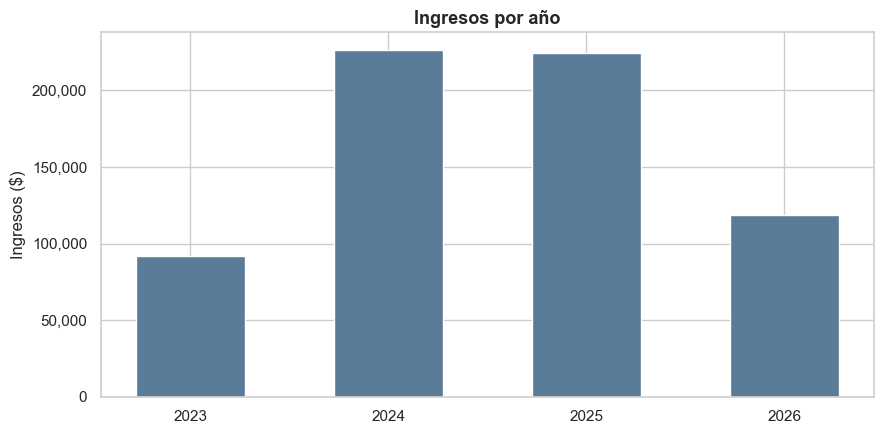

In [8]:
fig, ax = plt.subplots()
ax.bar(ventas_anio.index.astype(str), ventas_anio['Ingresos'], color=SOBER[0], width=0.55)
ax.set_title('Ingresos por año')
ax.set_ylabel('Ingresos ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

<div style="background-color:#EEF2F5; padding:13px 20px; border-radius:6px; margin:8px 0 20px 0;">
<p style="color:#4A4A4A; font-size:13.5px; line-height:1.6; margin:0;"><span style="color:#5B7C99; font-weight:600;">Lectura de negocio —</span> 2024 fue el año de mayor ingreso ($226,450), pero 2026 muestra una caída de -47% respecto a 2025 — la más pronunciada del periodo. Vale la pena investigar la causa (menor tráfico, catálogo, competencia).</p>
</div>

<div style="border-bottom:2px solid #5B7C99; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">1.2 Ventas por mes</h3>
</div>

In [37]:
ventas_mes = df_df.groupby(df_df['fecha_venta'].dt.to_period('M')).agg(
    Unidades=('cantidad', 'sum'),
    Ingresos=('Ingreso_Total', 'sum')
)
ventas_mes.index = ventas_mes.index.to_timestamp()
ventas_mes.tail(12)

,Unidades,Ingresos
fecha_venta,,
2026-01-01,76,13135.0
2026-02-01,97,16545.0
2026-03-01,96,15895.0
2026-04-01,78,12840.0
2026-05-01,57,11005.0
2026-06-01,78,12945.0
2026-07-01,72,13990.0
2026-08-01,52,9490.0
2026-09-01,24,3895.0


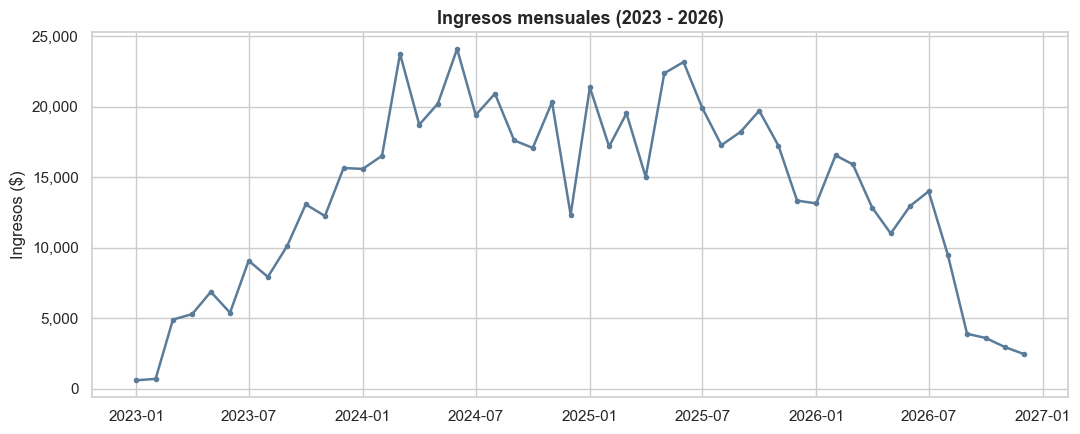

In [38]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(ventas_mes.index, ventas_mes['Ingresos'], color=SOBER[0], linewidth=1.8, marker='o', markersize=3)
ax.set_title('Ingresos mensuales (2023 - 2026)')
ax.set_ylabel('Ingresos ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

<div style="border-bottom:2px solid #5B7C99; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">1.3 Estacionalidad (mes del año)</h3>
</div>

In [39]:
meses_es = {1:'Enero',2:'Febrero',3:'Marzo',4:'Abril',5:'Mayo',6:'Junio',7:'Julio',8:'Agosto',9:'Septiembre',10:'Octubre',11:'Noviembre',12:'Diciembre'}
orden_meses = list(meses_es.values())
estacional = df_df.groupby(df_df['fecha_venta'].dt.month).agg(Unidades=('cantidad', 'sum'), Ingresos=('Ingreso_Total', 'sum'))
estacional.index = estacional.index.map(meses_es)
estacional = estacional.reindex(orden_meses)
estacional.sort_values('Ingresos', ascending=False)

,Unidades,Ingresos
fecha_venta,,
Junio,376,65575.0
Marzo,383,64050.0
Julio,388,62380.0
Mayo,379,60440.0
Agosto,336,55595.0
Octubre,333,53440.0
Noviembre,319,52730.0
Abril,332,51855.0
Febrero,303,50930.0


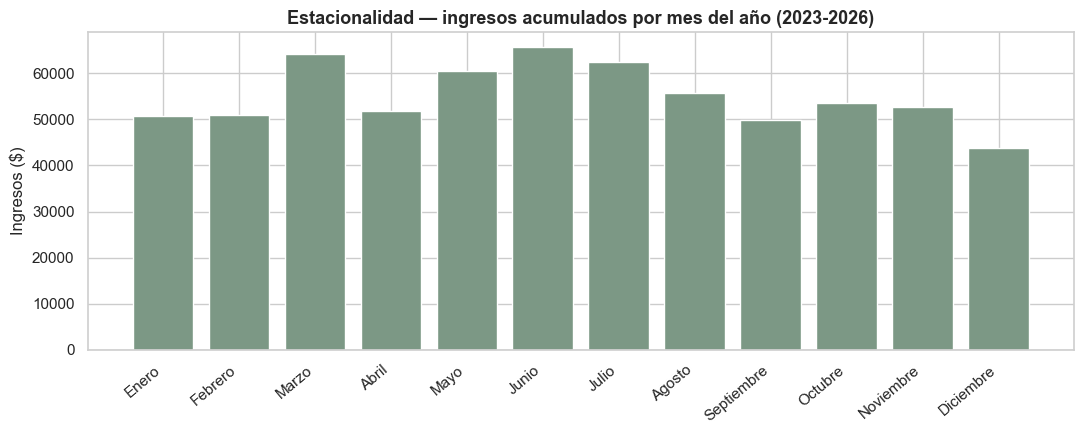

In [40]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(estacional.index, estacional['Ingresos'], color=SOBER[1])
ax.set_title('Estacionalidad — ingresos acumulados por mes del año (2023-2026)')
ax.set_ylabel('Ingresos ($)')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

<div style="background-color:#EEF2F5; padding:13px 20px; border-radius:6px; margin:8px 0 20px 0;">
<p style="color:#4A4A4A; font-size:13.5px; line-height:1.6; margin:0;"><span style="color:#5B7C99; font-weight:600;">Lectura de negocio —</span> Junio, marzo y julio concentran los mayores ingresos históricos; diciembre es el mes más bajo. Esto sugiere reforzar inventario y campañas antes del segundo trimestre, en vez de asumir que diciembre (temporada navideña tradicional) es el pico de ventas.</p>
</div>

<div style="border-bottom:2px solid #5B7C99; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">1.4 Ventas por día de la semana</h3>
</div>

In [41]:
dias_es = {0:'Lunes',1:'Martes',2:'Miércoles',3:'Jueves',4:'Viernes',5:'Sábado',6:'Domingo'}
orden_dias = list(dias_es.values())
df_df['dia_semana'] = df_df['fecha_venta'].dt.dayofweek.map(dias_es)
ventas_dia = df_df.groupby('dia_semana').agg(Unidades=('cantidad', 'sum'), Ingresos=('Ingreso_Total', 'sum')).reindex(orden_dias)
ventas_dia

,Unidades,Ingresos
dia_semana,,
Lunes,576,96150.0
Martes,547,89015.0
Miércoles,551,88145.0
Jueves,622,99450.0
Viernes,585,91760.0
Sábado,576,99215.0
Domingo,578,97535.0


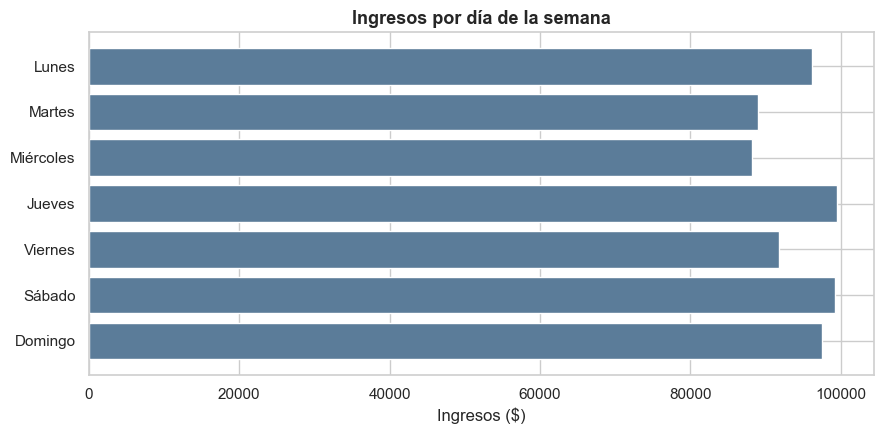

In [42]:
fig, ax = plt.subplots()
ax.barh(ventas_dia.index[::-1], ventas_dia['Ingresos'][::-1], color=SOBER[0])
ax.set_title('Ingresos por día de la semana')
ax.set_xlabel('Ingresos ($)')
plt.tight_layout()
plt.show()

<div style="border-bottom:2px solid #5B7C99; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">1.5 Año con mayor numero de ventas</h3>
</div>

In [43]:
anio_top = ventas_anio['Ingresos'].idxmax()
anio_top_datos = ventas_anio.loc[anio_top]

print(f"Año con mayor ventas: {anio_top}")
print(f"Ingresos: ${anio_top_datos['Ingresos']:,.2f}")
print(f"Unidades: {anio_top_datos['Unidades']:.0f}")
print(f"Utilidad: ${anio_top_datos['Utilidad']:,.2f}")

Año con mayor ventas: 2024
Ingresos: $226,450.00
Unidades: 1402
Utilidad: $155,723.00


<div style="background-color:#EEF4F0; border-left:4px solid #7C9885; padding:20px 28px; border-radius:6px; margin:28px 0 18px 0;">
<p style="color:#7C9885; font-size:12px; font-weight:600; letter-spacing:1.5px; text-transform:uppercase; margin:0 0 6px 0;">Sección 2</p>
<h2 style="color:#2C2C2C; margin:0 0 6px 0; font-size:21px; font-weight:600;">Productos</h2>
<p style="color:#5A5A5A; font-size:13.5px; line-height:1.6; margin:0;">Qué se vende más, qué se vende menos, y qué tan rentable es cada producto y categoría.</p>
</div>

<div style="border-bottom:2px solid #7C9885; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">2.1 Productos más y menos vendidos</h3>
</div>

In [45]:
productos_rank = df_df.groupby('nombre').agg(
    Unidades=('cantidad', 'sum'),
    Ingresos=('Ingreso_Total', 'sum'),
    Utilidad=('Utilidad', 'sum')
).sort_values('Unidades', ascending=False)
productos_rank['Margen_%'] = (productos_rank['Utilidad'] / productos_rank['Ingresos'] * 100).round(1)
productos_rank

,Unidades,Ingresos,Utilidad,Margen_%
nombre,,,,
Libreta de Tareas,552,60720.0,44160.0,72.7
Cómic Físico,545,81750.0,57225.0,70.0
Lapicera Colección,515,48925.0,36050.0,73.7
Peluche Personaje Coleccionable,507,141960.0,96330.0,67.9
Botella de Agua,493,59160.0,41905.0,70.8
Cómic Virtual,485,38800.0,36375.0,93.8
Mochila Ergonómica,475,213750.0,128250.0,60.0
Planilla Stickers,463,16205.0,12501.0,77.1


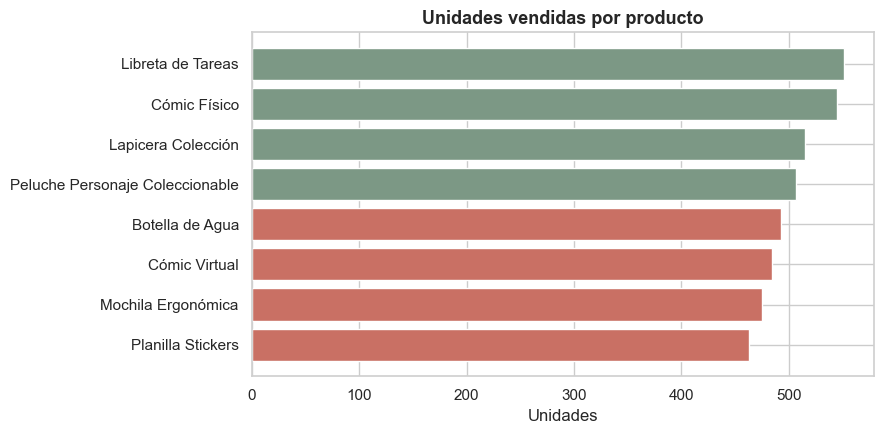

In [46]:
fig, ax = plt.subplots(figsize=(9, 4.5))
orden = productos_rank.sort_values('Unidades')
colores = [SOBER[1] if v >= orden['Unidades'].median() else SOBER[4] for v in orden['Unidades']]
ax.barh(orden.index, orden['Unidades'], color=colores)
ax.set_title('Unidades vendidas por producto')
ax.set_xlabel('Unidades')
plt.tight_layout()
plt.show()

<div style="background-color:#EEF4F0; padding:13px 20px; border-radius:6px; margin:8px 0 20px 0;">
<p style="color:#4A4A4A; font-size:13.5px; line-height:1.6; margin:0;"><span style="color:#7C9885; font-weight:600;">Lectura de negocio —</span> Libreta de Tareas y Cómic Oficial (Físico) lideran en unidades, pero eso no significa que sean los más rentables — ver la sección 2.3.</p>
</div>

<div style="border-bottom:2px solid #7C9885; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">2.2 Utilidad total por producto</h3>
</div>

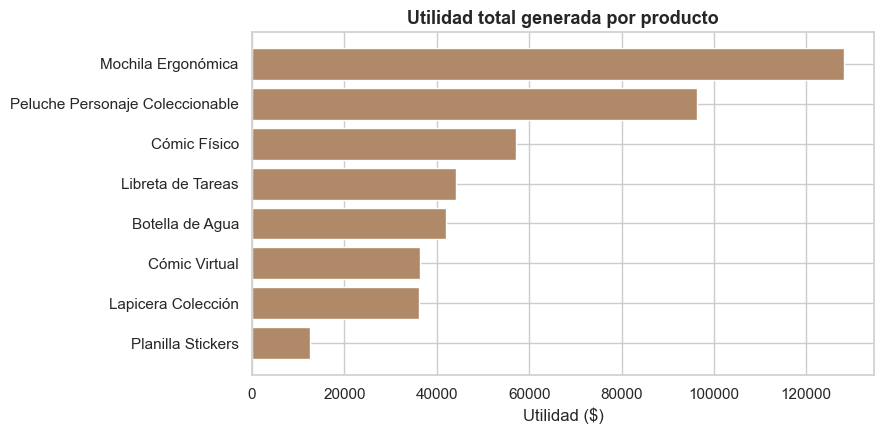

In [47]:
fig, ax = plt.subplots(figsize=(9, 4.5))
orden_ut = productos_rank.sort_values('Utilidad')
ax.barh(orden_ut.index, orden_ut['Utilidad'], color=SOBER[2])
ax.set_title('Utilidad total generada por producto')
ax.set_xlabel('Utilidad ($)')
plt.tight_layout()
plt.show()

<div style="background-color:#EEF4F0; padding:13px 20px; border-radius:6px; margin:8px 0 20px 0;">
<p style="color:#4A4A4A; font-size:13.5px; line-height:1.6; margin:0;"><span style="color:#7C9885; font-weight:600;">Lectura de negocio —</span> Mochila Ergonómica no es el producto más vendido en unidades, pero sí el que más utilidad total genera ($128,250) — es el producto ancla del negocio. Planilla Stickers, en cambio, vende bien pero deja la menor utilidad total, aunque tiene el margen porcentual más alto.</p>
</div>

<div style="border-bottom:2px solid #7C9885; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">2.3 Rentabilidad por categoría</h3>
</div>

In [48]:
categoria_rank = df_df.groupby('categoria').agg(
    Ingresos=('Ingreso_Total', 'sum'),
    Costos=('Costo_Total', 'sum'),
    Utilidad=('Utilidad', 'sum')
)
categoria_rank['Margen_%'] = (categoria_rank['Utilidad'] / categoria_rank['Ingresos'] * 100).round(1)
categoria_rank.sort_values('Margen_%', ascending=False)

,Ingresos,Costos,Utilidad,Margen_%
categoria,,,,
Lectura,120550.0,26950.0,93600.0,77.6
Papelería,125850.0,33139.0,92711.0,73.7
Peluches,141960.0,45630.0,96330.0,67.9
Accesorios,272910.0,102755.0,170155.0,62.3


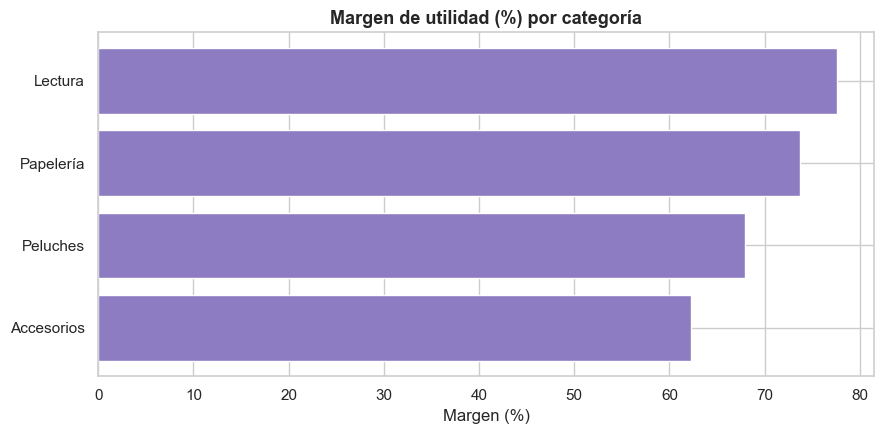

In [49]:
fig, ax = plt.subplots()
orden_cat = categoria_rank.sort_values('Margen_%')
ax.barh(orden_cat.index, orden_cat['Margen_%'], color=SOBER[3])
ax.set_title('Margen de utilidad (%) por categoría')
ax.set_xlabel('Margen (%)')
plt.tight_layout()
plt.show()

<div style="border-bottom:2px solid #7C9885; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">2.4 Panorama de productos: volumen vs. margen</h3>
</div>

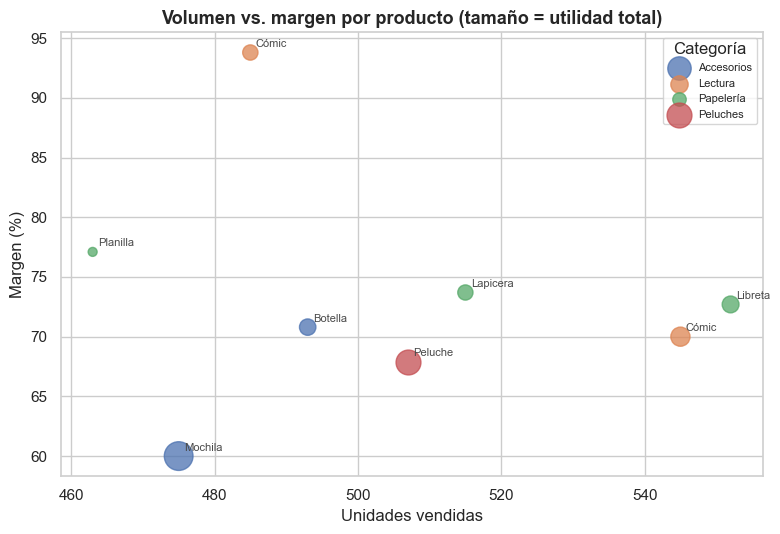

In [50]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for cat, grupo in productos_rank.join(df_df.groupby('nombre')['categoria'].first()).groupby('categoria'):
    ax.scatter(grupo['Unidades'], grupo['Margen_%'], s=grupo['Utilidad']/300, alpha=0.75, label=cat)
for nombre, row in productos_rank.iterrows():
    ax.annotate(nombre.split(' ')[0], (row['Unidades'], row['Margen_%']), fontsize=8, color='#4A4A4A',
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Unidades vendidas')
ax.set_ylabel('Margen (%)')
ax.set_title('Volumen vs. margen por producto (tamaño = utilidad total)')
ax.legend(title='Categoría', fontsize=8)
plt.tight_layout()
plt.show()

<div style="background-color:#F6F1EC; border-left:4px solid #B08968; padding:20px 28px; border-radius:6px; margin:28px 0 18px 0;">
<p style="color:#B08968; font-size:12px; font-weight:600; letter-spacing:1.5px; text-transform:uppercase; margin:0 0 6px 0;">Sección 3</p>
<h2 style="color:#2C2C2C; margin:0 0 6px 0; font-size:21px; font-weight:600;">Clientes / Jugadores</h2>
<p style="color:#5A5A5A; font-size:13.5px; line-height:1.6; margin:0;">Quiénes compran más, y cómo se relaciona el tipo de suscripción con el gasto en la tienda física.</p>
</div>

<div style="border-bottom:2px solid #B08968; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">3.1 Top 10 clientes por gasto</h3>
</div>

In [51]:
top_clientes = df_df.groupby(['jugador_id', 'tipo_suscripcion']).agg(
    Compras_Totales=('cantidad', 'sum'),
    Gasto_Total=('Ingreso_Total', 'sum')
).reset_index().sort_values('Gasto_Total', ascending=False).head(10)
top_clientes

,jugador_id,tipo_suscripcion,Compras_Totales,Gasto_Total
223,JUG-224,Gratuita,41,7230.0
212,JUG-213,Gratuita,35,6790.0
178,JUG-179,Gratuita,29,6125.0
205,JUG-206,Gratuita,36,6105.0
195,JUG-196,Gratuita,35,5475.0
42,JUG-043,Premium,29,5230.0
138,JUG-139,Gratuita,20,5180.0
234,JUG-235,Gratuita,32,5135.0
52,JUG-053,Gratuita,24,5120.0
220,JUG-221,Gratuita,26,4985.0


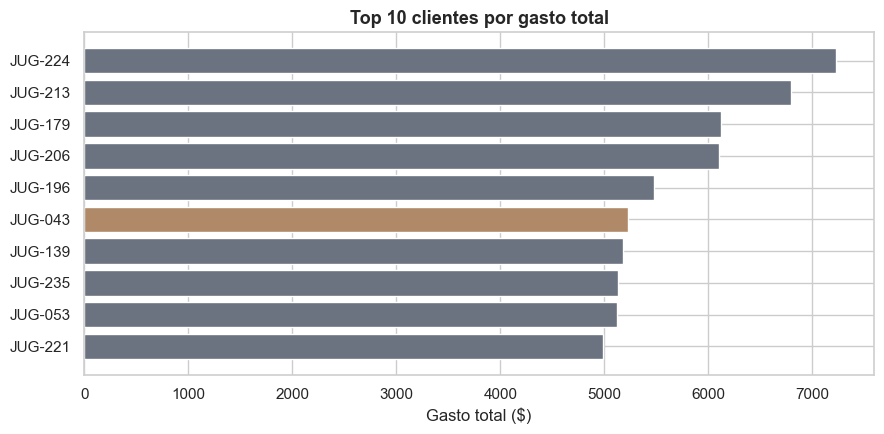

In [52]:
fig, ax = plt.subplots()
colores = [SOBER[2] if s == 'Premium' else SOBER[5] for s in top_clientes['tipo_suscripcion']]
ax.barh(top_clientes['jugador_id'][::-1], top_clientes['Gasto_Total'][::-1], color=colores[::-1])
ax.set_title('Top 10 clientes por gasto total')
ax.set_xlabel('Gasto total ($)')
plt.tight_layout()
plt.show()

<div style="border-bottom:2px solid #B08968; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">3.2 Suscripción vs. comportamiento de compra</h3>
</div>

In [53]:
jugadores_unicos = df_df.drop_duplicates('jugador_id')
dist_suscripcion = jugadores_unicos['tipo_suscripcion'].value_counts()

gasto_por_tipo = df_df.groupby('tipo_suscripcion').agg(
    Jugadores=('jugador_id', 'nunique'),
    Gasto_Total=('Ingreso_Total', 'sum')
)
gasto_por_tipo['Gasto_Promedio_Jugador'] = (gasto_por_tipo['Gasto_Total'] / gasto_por_tipo['Jugadores']).round(2)
gasto_por_tipo

,Jugadores,Gasto_Total,Gasto_Promedio_Jugador
tipo_suscripcion,,,
Gratuita,192,510640.0,2659.58
Premium,58,150630.0,2597.07


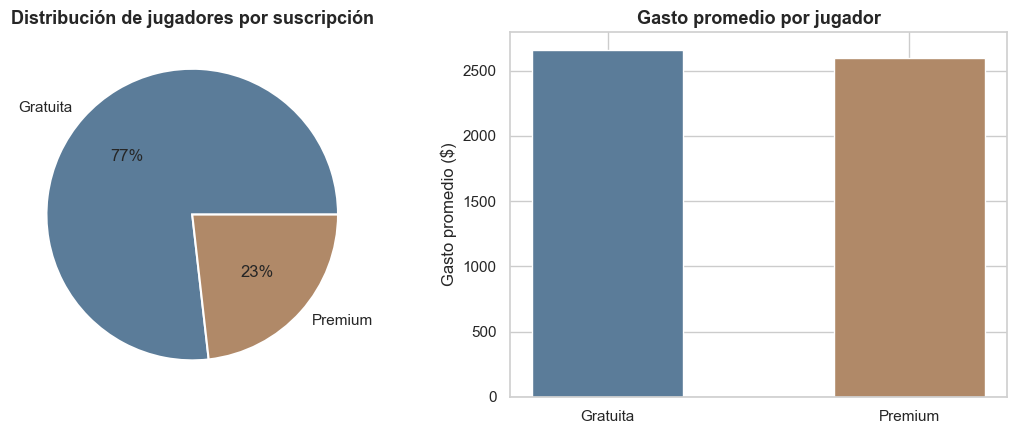

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].pie(dist_suscripcion, labels=dist_suscripcion.index, autopct='%1.0f%%',
            colors=[SOBER[0], SOBER[2]], wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Distribución de jugadores por suscripción')

axes[1].bar(gasto_por_tipo.index, gasto_por_tipo['Gasto_Promedio_Jugador'], color=[SOBER[0], SOBER[2]], width=0.5)
axes[1].set_title('Gasto promedio por jugador')
axes[1].set_ylabel('Gasto promedio ($)')
plt.tight_layout()
plt.show()

<div style="background-color:#F6F1EC; padding:13px 20px; border-radius:6px; margin:8px 0 20px 0;">
<p style="color:#4A4A4A; font-size:13.5px; line-height:1.6; margin:0;"><span style="color:#B08968; font-weight:600;">Lectura de negocio —</span> Solo el 23% de los jugadores tiene suscripción Premium, pero conviene revisar el gasto promedio por jugador entre ambos grupos: si no hay diferencia clara, la suscripción Premium no está traduciéndose en mayor consumo de mercancía física, y el equipo de Producto podría diseñar una promoción cruzada.</p>
</div>

<div style="background-color:#EFF1F2; border-left:4px solid #5C6B73; padding:20px 28px; border-radius:6px; margin:28px 0 18px 0;">
<p style="color:#5C6B73; font-size:12px; font-weight:600; letter-spacing:1.5px; text-transform:uppercase; margin:0 0 6px 0;">Sección 4</p>
<h2 style="color:#2C2C2C; margin:0 0 6px 0; font-size:21px; font-weight:600;">Geografía</h2>
<p style="color:#5A5A5A; font-size:13.5px; line-height:1.6; margin:0;">En qué municipios y zonas de Puebla se concentra la venta, y dónde hay oportunidad de crecer.</p>
</div>

<div style="border-bottom:2px solid #5C6B73; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">4.1 Ranking de municipios</h3>
</div>

In [55]:
municipios_rank = df_df.groupby('municipio').agg(
    Unidades=('cantidad', 'sum'),
    Ingresos=('Ingreso_Total', 'sum')
).sort_values('Ingresos', ascending=False)
municipios_rank

,Unidades,Ingresos
municipio,,
San Andrés Cholula,736,119100.0
Heroica Puebla De Zaragoza,536,85475.0
Tehuacán,382,61245.0
Atlixco,333,56400.0
Amozoc De Mota,303,51050.0
Chignahuapan,327,49890.0
Cuautlancingo (San Lorenzo Almecatla),280,47605.0
Puebla (Centro),275,45435.0
Huauchinango,218,34855.0


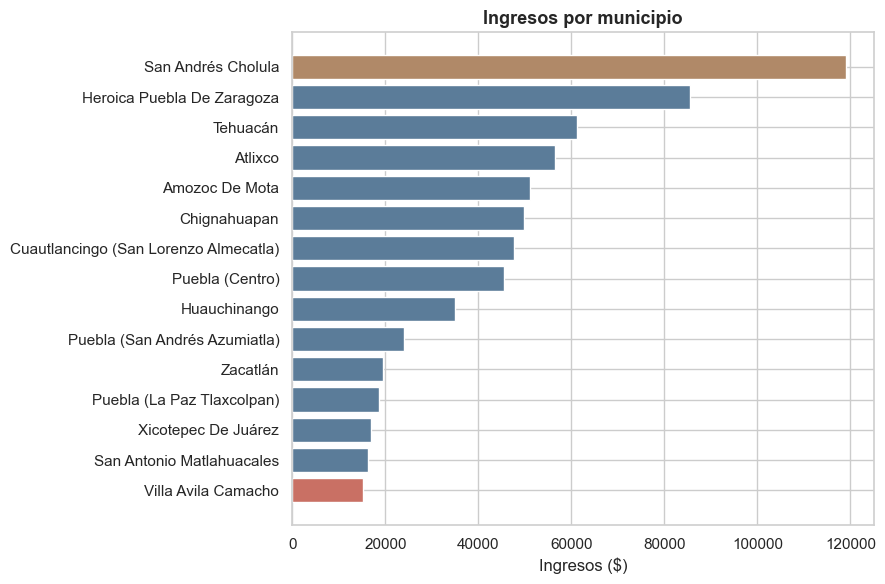

In [56]:
fig, ax = plt.subplots(figsize=(9, 6))
orden_mun = municipios_rank.sort_values('Ingresos')
colores = [SOBER[0]] * len(orden_mun)
colores[-1] = SOBER[2]
colores[0] = SOBER[4]
ax.barh(orden_mun.index, orden_mun['Ingresos'], color=colores)
ax.set_title('Ingresos por municipio')
ax.set_xlabel('Ingresos ($)')
plt.tight_layout()
plt.show()

<div style="background-color:#EFF1F2; padding:13px 20px; border-radius:6px; margin:8px 0 20px 0;">
<p style="color:#4A4A4A; font-size:13.5px; line-height:1.6; margin:0;"><span style="color:#5C6B73; font-weight:600;">Lectura de negocio —</span> San Andrés Cholula concentra el mayor ingreso ($119,100), casi 40% más que Heroica Puebla de Zaragoza, el segundo lugar. Villa Ávila Camacho es el municipio con menor actividad — candidato a evaluar si vale la pena mantener distribución ahí o consolidar envíos con un municipio cercano.</p>
</div>

<div style="border-bottom:2px solid #5C6B73; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">4.2 Mapa de zonas de venta</h3>
</div>

In [57]:
geo_zonas = df_df.groupby(['municipio', 'latitud', 'longitud']).agg(
    Ventas=('cantidad', 'sum'),
    Utilidad=('Utilidad', 'sum')
).reset_index()

v_min, v_max = geo_zonas['Ventas'].min(), geo_zonas['Ventas'].max()
geo_zonas['radio'] = 4 + 14 * (geo_zonas['Ventas'] - v_min) / (v_max - v_min)

mapa_zonas = folium.Map(location=[19.35, -97.95], zoom_start=8, tiles='CartoDB positron')

for _, row in geo_zonas.iterrows():
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=row['radio'],
        popup=f"<b>{row['municipio']}</b><br>Ventas: {row['Ventas']} unidades<br>Utilidad: ${row['Utilidad']:,.2f}",
        color='#5B7C99',
        fill=True,
        fill_color='#5B7C99',
        fill_opacity=0.45,
        weight=1
    ).add_to(mapa_zonas)

mapa_zonas

<div style="background-color:#EFF1F2; padding:13px 20px; border-radius:6px; margin:8px 0 20px 0;">
<p style="color:#4A4A4A; font-size:13.5px; line-height:1.6; margin:0;"><span style="color:#5C6B73; font-weight:600;">Lectura de negocio —</span> El tamaño de cada burbuja está normalizado entre un radio mínimo y máximo fijo, para que las zonas de mayor venta no dominen visualmente el mapa ni las de menor venta desaparezcan.</p>
</div>

<div style="border-bottom:2px solid #5C6B73; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">4.3 Mapa de calor de densidad de venta</h3>
</div>

In [58]:
mapa_calor = folium.Map(location=[19.35, -97.95], zoom_start=8, tiles='CartoDB positron')
puntos_calor = df_df.groupby(['latitud', 'longitud'])['cantidad'].sum().reset_index().values.tolist()
HeatMap(puntos_calor, radius=18, blur=22, min_opacity=0.35).add_to(mapa_calor)
mapa_calor

<div style="background-color:#F1EFF7; border-left:4px solid #8E7CC3; padding:20px 28px; border-radius:6px; margin:28px 0 18px 0;">
<p style="color:#8E7CC3; font-size:12px; font-weight:600; letter-spacing:1.5px; text-transform:uppercase; margin:0 0 6px 0;">Sección 5</p>
<h2 style="color:#2C2C2C; margin:0 0 6px 0; font-size:21px; font-weight:600;">Rentabilidad en el tiempo</h2>
<p style="color:#5A5A5A; font-size:13.5px; line-height:1.6; margin:0;">Cómo evoluciona la utilidad y el margen mes a mes, más allá del volumen de ventas.</p>
</div>

<div style="border-bottom:2px solid #8E7CC3; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">5.1 Utilidad mensual</h3>
</div>

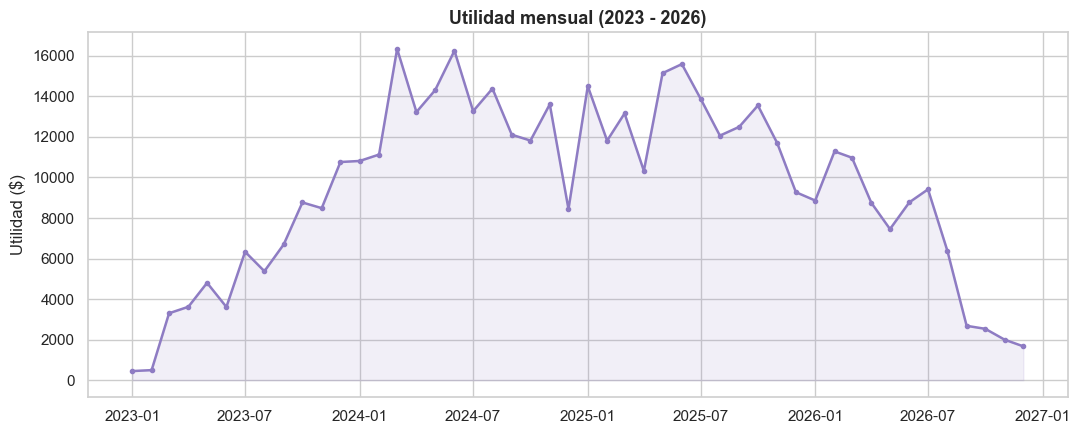

In [59]:
utilidad_mensual = df_df.groupby(df_df['fecha_venta'].dt.to_period('M'))['Utilidad'].sum()
utilidad_mensual.index = utilidad_mensual.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(utilidad_mensual.index, utilidad_mensual.values, color=SOBER[3], linewidth=1.8, marker='o', markersize=3)
ax.fill_between(utilidad_mensual.index, utilidad_mensual.values, color=SOBER[3], alpha=0.12)
ax.set_title('Utilidad mensual (2023 - 2026)')
ax.set_ylabel('Utilidad ($)')
plt.tight_layout()
plt.show()

<div style="border-bottom:2px solid #8E7CC3; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">5.2 Margen de utilidad mensual (%)</h3>
</div>

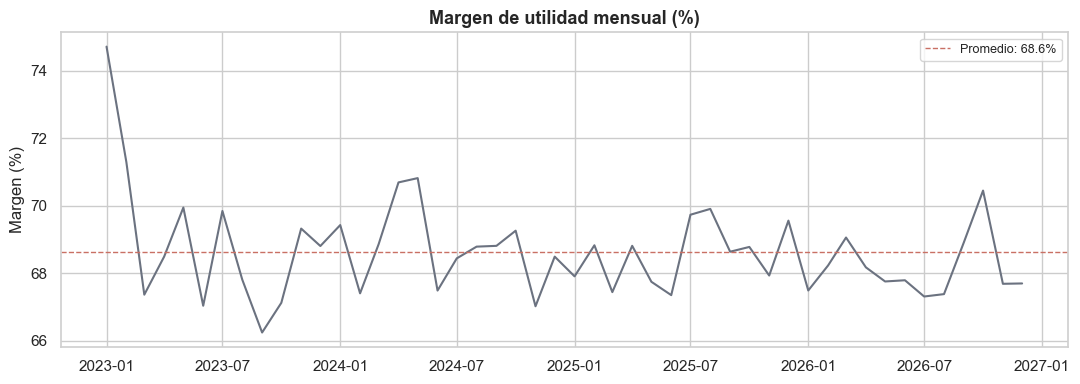

In [60]:
margen_mensual = df_df.groupby(df_df['fecha_venta'].dt.to_period('M')).apply(
    lambda x: x['Utilidad'].sum() / x['Ingreso_Total'].sum() * 100
)
margen_mensual.index = margen_mensual.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(margen_mensual.index, margen_mensual.values, color=SOBER[5], linewidth=1.5)
ax.axhline(margen_mensual.mean(), color=SOBER[4], linestyle='--', linewidth=1, label=f'Promedio: {margen_mensual.mean():.1f}%')
ax.set_title('Margen de utilidad mensual (%)')
ax.set_ylabel('Margen (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

<div style="background-color:#F1EFF7; padding:13px 20px; border-radius:6px; margin:8px 0 20px 0;">
<p style="color:#4A4A4A; font-size:13.5px; line-height:1.6; margin:0;"><span style="color:#8E7CC3; font-weight:600;">Lectura de negocio —</span> El margen se mantiene estable alrededor de 68-69% durante los 4 años (desviación estándar de solo 1.4 puntos porcentuales), incluso en 2026 cuando cae el volumen de ventas. Esto indica que la caída de ingresos de 2026 es un problema de volumen (menos unidades vendidas), no de precios ni de estructura de costos.</p>
</div>

<div style="background-color:#F3F4F6; border-left:4px solid #6B7280; padding:20px 28px; border-radius:6px; margin:28px 0 18px 0;">
<p style="color:#6B7280; font-size:12px; font-weight:600; letter-spacing:1.5px; text-transform:uppercase; margin:0 0 6px 0;">Sección 6</p>
<h2 style="color:#2C2C2C; margin:0 0 6px 0; font-size:21px; font-weight:600;">Conclusiones y recomendaciones</h2>
<p style="color:#5A5A5A; font-size:13.5px; line-height:1.6; margin:0;">Síntesis de los hallazgos más accionables de este análisis.</p>
</div>

<div style="background-color:#F9FAFB; padding:24px 30px; border-radius:6px; border:1px solid #E1E4E8;">
<ol style="color:#3A3A3A; font-size:14px; line-height:2.0; margin:0; padding-left:20px;">
<li><b>Concentración geográfica alta:</b> San Andrés Cholula y Heroica Puebla de Zaragoza generan cerca de la mitad del ingreso total. Cualquier campaña de marketing dirigido debería priorizar estas zonas antes de expandirse.</li>
<li><b>Caída de ventas en 2026:</b> los ingresos cayeron 47% respecto a 2025, mientras el margen se mantuvo estable. El problema es de volumen, no de rentabilidad por unidad — conviene investigar tráfico, catálogo o competencia antes de ajustar precios.</li>
<li><b>Mochila Ergonómica es el producto ancla:</b> genera la mayor utilidad total del catálogo, aunque no es el más vendido en unidades. Debería tener prioridad de inventario.</li>
<li><b>La suscripción Premium no se traduce claramente en mayor gasto en mercancía física</b> — los jugadores con suscripción Gratuita dominan el top de clientes por gasto total. Hay oportunidad de cross-selling hacia los usuarios Premium.</li>
<li><b>Estacionalidad marcada:</b> junio, marzo y julio concentran más ventas que diciembre, distinto al patrón "temporada navideña" que suele asumirse en retail físico.</li>
</ol>
</div>